In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

## Load Data

# 📊 Student Performance Dataset Attributes

### Common Attributes (for both `student-mat.csv` and `student-por.csv`)

1. **school** – Student's school  
   - Binary: `GP` (Gabriel Pereira) or `MS` (Mousinho da Silveira)

2. **sex** – Student's sex  
   - Binary: `F` (female) or `M` (male)

3. **age** – Student's age  
   - Numeric: 15 to 22

4. **address** – Home address type  
   - Binary: `U` (urban) or `R` (rural)

5. **famsize** – Family size  
   - Binary: `LE3` (≤3) or `GT3` (>3)

6. **Pstatus** – Parent's cohabitation status  
   - Binary: `T` (living together) or `A` (apart)

7. **Medu** – Mother's education  
   - Numeric:  
     - 0 = none  
     - 1 = primary (4th grade)  
     - 2 = 5th–9th grade  
     - 3 = secondary education  
     - 4 = higher education  

8. **Fedu** – Father's education  
   - Numeric (same scale as `Medu`)

9. **Mjob** – Mother's job  
   - Nominal: `teacher`, `health`, `services`, `at_home`, `other`

10. **Fjob** – Father's job  
    - Nominal: `teacher`, `health`, `services`, `at_home`, `other`

11. **reason** – Reason to choose this school  
    - Nominal: `home`, `reputation`, `course`, `other`

12. **guardian** – Student's guardian  
    - Nominal: `mother`, `father`, `other`

13. **traveltime** – Home-to-school travel time  
    - Numeric:  
      - 1 = <15 min  
      - 2 = 15–30 min  
      - 3 = 30–60 min  
      - 4 = >1 hour  

14. **studytime** – Weekly study time  
    - Numeric:  
      - 1 = <2 hours  
      - 2 = 2–5 hours  
      - 3 = 5–10 hours  
      - 4 = >10 hours  

15. **failures** – Past class failures  
    - Numeric: `n` if 1 ≤ n < 3, else 4

16. **schoolsup** – Extra educational support  
    - Binary: `yes` or `no`

17. **famsup** – Family educational support  
    - Binary: `yes` or `no`

18. **paid** – Extra paid classes (Math or Portuguese)  
    - Binary: `yes` or `no`

19. **activities** – Extra-curricular activities  
    - Binary: `yes` or `no`

20. **nursery** – Attended nursery school  
    - Binary: `yes` or `no`

21. **higher** – Aspires to higher education  
    - Binary: `yes` or `no`

22. **internet** – Internet access at home  
    - Binary: `yes` or `no`

23. **romantic** – In a romantic relationship  
    - Binary: `yes` or `no`

24. **famrel** – Quality of family relationships  
    - Numeric: 1 (very bad) → 5 (excellent)

25. **freetime** – Free time after school  
    - Numeric: 1 (very low) → 5 (very high)

26. **goout** – Going out with friends  
    - Numeric: 1 (very low) → 5 (very high)

27. **Dalc** – Workday alcohol consumption  
    - Numeric: 1 (very low) → 5 (very high)

28. **Walc** – Weekend alcohol consumption  
    - Numeric: 1 (very low) → 5 (very high)

29. **health** – Current health status  
    - Numeric: 1 (very bad) → 5 (very good)

30. **absences** – Number of school absences  
    - Numeric: 0 → 93

---

### 🎓 Course-Specific Grades

31. **G1** – First period grade (0–20)  
32. **G2** – Second period grade (0–20)  
33. **G3** – Final grade (0–20, output target)


In [22]:
df = pd.read_csv('../data/raw/student-mat.csv',sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Overview

In [23]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


No.of rows = 395,
No.of columns = 33,
No missing values.

## Missing Values Analysis

In [28]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


## Understand the Target (Grades)

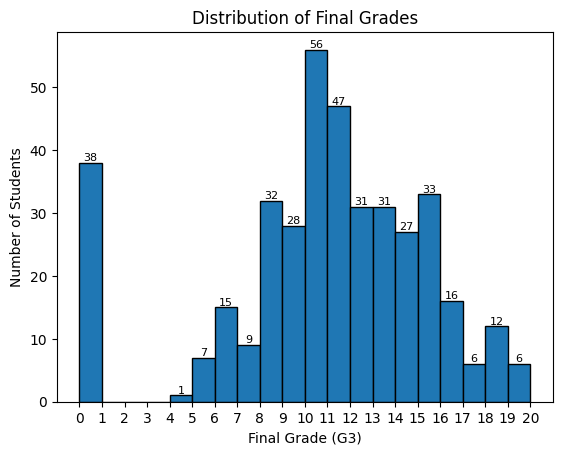

In [46]:
counts, bin_edges, patches =plt.hist(df["G3"], bins=np.arange(0, 21, 1), edgecolor='black')
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.xticks(np.arange(0, 21, 1))
for count, edge in zip(counts, bin_edges[:-1]):
    if count > 0: # only label non-empty bins
        plt.text(edge + 0.5, count, str(int(count)), ha='center', va='bottom', fontsize=8)
plt.show()

## At risk:

In [47]:
df["at_risk"] = (df["G3"] < 10).astype(int)
df["at_risk"].value_counts()

at_risk
0    265
1    130
Name: count, dtype: int64

## Distribution Analysis

In [25]:
# Visualize distributions
# df.hist(figsize=(15, 10))
# plt.tight_layout()
# plt.show()

## Correlation Analysis

In [26]:
# Correlation matrix
# plt.figure(figsize=(12, 8))
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
# plt.title('Correlation Matrix')
# plt.show()